# Dylan Navarro Badilla

## Práctica 2

Usando el dataset *obesity.csv* y guiándose con la descripción de sus variables en el archivo *obesity_description.txt*:

1. Implemente un modelo de regresión que estime el **peso** de una persona a partir de su **altura** y **edad**. Luego, imprima en pantalla la métrica $R^2$ para medir el desempeño del modelo.

2. Aumente la complejidad del modelo de regresión y agregue variales independientes (númericas y/o categóricas) tanto como se requiera, con el fin de mejorar las métricas de evaluación. Despliegue en la sesión de trabajo los resultados respectivos.

3. Implemente un modelo de clasificación que estime el grado de obesidad de una persona (*NObeyesdad*) basado únicamente en atributos de su **hábitos de alimentación**. Luego, imprima en pantalla la exactitud del modelo y su matriz de confusión.

4. Implementre otro modelo de clasificación que estime el *NObeyesdad* de una persona basado únicamente en atributos relacionados con su **condición física**. Luego, imprima en pantalla la exactitud del modelo y su matriz de confusión.

5. **Opcional**: ¿Cual de los dos modelos logra predecir con mayor exactitud el grado de obesidad de una persona? ¿Cúal es la categoría de obesidad que presentó más falsos negativos para cada modelo? ¿Cúal es la categoría de obesidad que presentó más falsos positivos para cada modelo?

In [1]:
import pandas as pd #biblioteca para lectura de datos estructurados y su manipulación
import numpy as np  #biblioteca para realizar operaciones con vectores y matrices
import matplotlib.pyplot as plt #biblioteca para visualización de datos
from sklearn.linear_model import LogisticRegression #biblioteca de machine learning

### 1) Implemente un modelo de regresión que estime el **peso** de una persona a partir de su **altura** y **edad**. Luego, imprima en pantalla la métrica $R^2$ para medir el desempeño del modelo.
### Primero se sube el archivo csv necesario y se verifica el path:

In [2]:
! pwd
! ls

/content
obesity.csv  sample_data


### Luego se realiza una visualización de los datos para determinar el tipo de ajuste y estudiar las variables:

In [3]:
filepath = '/content/obesity.csv'
dataset = pd.read_csv(filepath, header=0)
dataset.shape

(2111, 17)

In [4]:
dataset.head(n=15)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


### En este caso, es necesario implementar una regresión lineal multivariada:

In [5]:
dataset[['Age', 'Height' , 'Weight']]

,Age,Height,Weight
0,21.000000,1.620000,64.000000
1,21.000000,1.520000,56.000000
2,23.000000,1.800000,77.000000
3,27.000000,1.800000,87.000000
4,22.000000,1.780000,89.800000
...,...,...,...
2106,20.976842,1.710730,131.408528
2107,21.982942,1.748584,133.742943
2108,22.524036,1.752206,133.689352
2109,24.361936,1.739450,133.346641


In [6]:
from sklearn.linear_model import LinearRegression
rl = LinearRegression()
x = dataset[['Age', 'Height']].values
y_tag = 'Weight'
y = dataset[[y_tag]].values
rl.fit(x, y)

#R2 usando RL y dos variables
rScore2 = rl.score(x, y)
print('Coeficiente de determinación para la regresión lineal bivariada:', rScore2)

Coeficiente de determinación para la regresión lineal bivariada: 0.2605716534154858


### El resultado de $R^2$ es muy bajo, lo que sugiere que pueden existir mejores ajustes (esto se hará en el punto 2). Ahora se realiza el gráfico de los datos:  

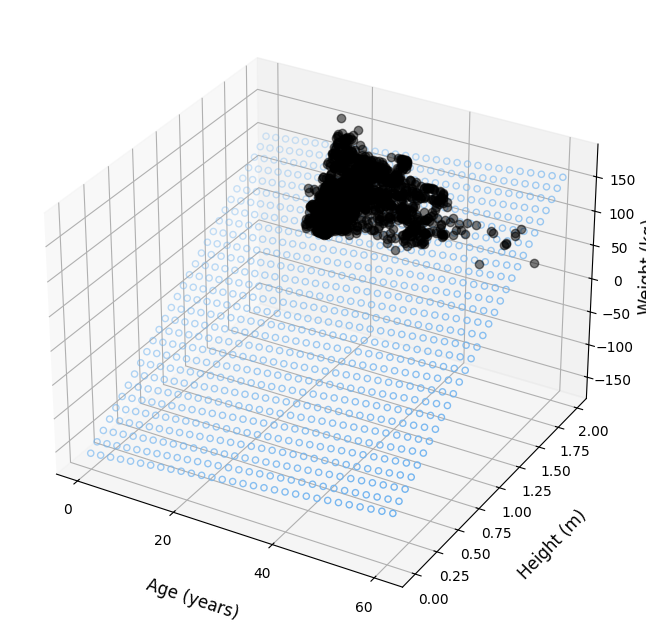

In [7]:
x9 = x[:, 0]
y9 = x[:, 1]
z9 = y

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
x_pred = np.linspace(0, np.max(x9), 30)
y_pred = np.linspace(0, np.max(y9), 30)
xx_pred, yy_pred = np.meshgrid(x_pred, y_pred)
model_viz = np.array([xx_pred.flatten(), yy_pred.flatten()]).T
newpred = rl.predict(model_viz)

ax.plot(x9, y9, z9.flatten(), color='k', zorder=15, linestyle='none', marker='o', alpha=0.5)
ax.scatter(xx_pred.flatten(), yy_pred.flatten(), newpred.flatten(), facecolor=(0,0,0,0), s=20, edgecolor='#70b3f0')
ax.set_xlabel('Age (years)', fontsize=12, labelpad=15)
ax.set_ylabel('Height (m)', fontsize=12, labelpad=15)
ax.set_zlabel('Weight (kg)', fontsize=12)
ax.locator_params(nbins=4, axis='x')
ax.locator_params(nbins=5, axis='x')

### Realizando un predict:

In [8]:
age = 23
height = 1.73
test_value = np.array([[age, height]])
pred_value = rl.predict(test_value)
print('Estimación del peso según la edad y la altura de la persona: {:.2f} kg'.format(pred_value[0][0]))

Estimación del peso según la edad y la altura de la persona: 89.15 kg


### 2) Aumente la complejidad del modelo de regresión y agregue variales independientes (númericas y/o categóricas) tanto como se requiera, con el fin de mejorar las métricas de evaluación. Despliegue en la sesión de trabajo los resultados respectivos.

In [9]:
dataset.head(n=5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### Se va a calcular $R^2$ con diferente número de variables para comprobar el set con un valor de $R^2 \approx 1$. Empezando por el género:

In [10]:
x_cat = pd.get_dummies(dataset[['Gender']])
#Concatenar variables categóricas y numéricas
x_num = dataset[['Age', 'Height']]
x4 = pd.concat([x_cat.reset_index(drop=True), x_num], axis=1) #concatenacion por columnas
x4 = x4.values

#Ajuste del modelo de regresión
rl4 = LinearRegression()  # create a linear regression model (object)
rl4.fit(x4, y)  # perform linear regression

#Valor R2
rScore4 = rl4.score(x4, y)
print('Coeficiente de determinación para la regresión lineal multivariada:', rScore4)

Coeficiente de determinación para la regresión lineal multivariada: 0.29189414821756676


### $R^2$ sigue siendo pequeño, se procede a realizar más pruebas:

In [11]:
x2_cat = pd.get_dummies(dataset[['Gender', 'family_history_with_overweight']])

x5 = pd.concat([x2_cat.reset_index(drop=True), x_num], axis=1) #concatenacion por columnas
x5 = x5.values

#Ajuste del modelo de regresión
rl5 = LinearRegression()  # create a linear regression model (object)
rl5.fit(x5, y)  # perform linear regression

#Valor R2
rScore5 = rl5.score(x5, y)
print('Coeficiente de determinación para la regresión lineal multivariada:', rScore5)

Coeficiente de determinación para la regresión lineal multivariada: 0.4088132061704105


In [12]:
x3_num = dataset[['Age', 'Height', 'FAF']]
x6 = pd.concat([x3_num.reset_index(drop=True), x2_cat.reset_index(drop=True)], axis=1)
x6 = x6.values
rl6 = LinearRegression()
rl6.fit(x6, y)
rScore6 = rl6.score(x6, y)
print('Coeficiente de determinación para la regresión lineal multivariada:', rScore6)

Coeficiente de determinación para la regresión lineal multivariada: 0.42482806499601045


### Para no ser tan repetitivo, le pedí a la IA que me diera el resultado con todas las variables:

In [13]:
x4_cat = pd.get_dummies(dataset[['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'CALC', 'MTRANS']])

x4_num = dataset[['Age', 'Height', 'FAF', 'CH2O', 'FCVC', 'NCP', 'TUE']]

x8 = pd.concat([x4_num.reset_index(drop=True), x4_cat.reset_index(drop=True)], axis=1)
x8 = x8.values

rl8 = LinearRegression()
rl8.fit(x8, y)

rScore8 = rl8.score(x8, y)
print('Coeficiente de determinación para la regresión lineal multivariada:', rScore8)

Coeficiente de determinación para la regresión lineal multivariada: 0.5820444452259542


### Como ya son todas las variables, entonces este resultado sería el valor máximo para $R^2$ que se puede obtener con este set de datos. Se podría decir que es el mejor modelo para predecir el peso, sin embargo, habría que agregar muchos datos para hacer una predicción.

### 3) Implemente un modelo de clasificación que estime el grado de obesidad de una persona (*NObeyesdad*) basado únicamente en atributos de su **hábitos de alimentación**. Luego, imprima en pantalla la exactitud del modelo y su matriz de confusión.

In [14]:
dataset.head(n=10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


### Según el archivo .txt, los atributos relacionados a los hábitos de alimentación son: FAVC, FCVC, NCP, CAEC, CH20 Y CALC. Para ello se puede implementar el modelo de regresión logística multivariada:

In [15]:
x_cat_al = pd.get_dummies(dataset[['CAEC', 'CALC', 'FAVC']])
x_num_al  = dataset[['FCVC', 'NCP', 'CH2O']]

x_al = pd.concat([x_num_al.reset_index(drop=True), x_cat_al.reset_index(drop=True)], axis=1).values

y_al = dataset['NObeyesdad'].values

logRegMultiVar = LogisticRegression(multi_class='multinomial')
logRegMultiVar = logRegMultiVar.fit(x_al, np.ravel(y_al))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Exactitud del modelo y matriz de confusión:

In [16]:
print('Exactitud del modelo de regresión multinomial usando 6 predictores:', logRegMultiVar.score(x_al, y_al))

Exactitud del modelo de regresión multinomial usando 6 predictores: 0.46234012316437706


In [17]:
from sklearn.metrics import confusion_matrix
predMultiVar = logRegMultiVar.predict(x_al)
cm2 = confusion_matrix(y_al, predMultiVar)
dfcm2 = pd.DataFrame(cm2)
dfcm2.columns = logRegMultiVar.classes_
dfcm2.index = logRegMultiVar.classes_
print(dfcm2)

                     Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
Insufficient_Weight                  117             23              53   
Normal_Weight                         64             63              50   
Obesity_Type_I                         4              9             223   
Obesity_Type_II                        2              3              87   
Obesity_Type_III                       1              0               0   
Overweight_Level_I                     7             14              76   
Overweight_Level_II                   13             10             139   

                     Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
Insufficient_Weight               42                27                   1   
Normal_Weight                     42                20                  10   
Obesity_Type_I                    76                27                   2   
Obesity_Type_II                  150                49                   1   
Obesity_T

### Sin nombres para mejor visualización:

In [18]:
predMultiVar = logRegMultiVar.predict(x_al)
cm2 = confusion_matrix(y_al, predMultiVar)
dfcm2 = pd.DataFrame(cm2)
print(dfcm2)

     0   1    2    3    4   5   6
0  117  23   53   42   27   1   9
1   64  63   50   42   20  10  38
2    4   9  223   76   27   2  10
3    2   3   87  150   49   1   5
4    1   0    0    0  322   0   1
5    7  14   76  102   40  36  15
6   13  10  139   44    9  10  65


### 4) Implementre otro modelo de clasificación que estime el *NObeyesdad* de una persona basado únicamente en atributos relacionados con su **condición física**. Luego, imprima en pantalla la exactitud del modelo y su matriz de confusión.

### Según el archivo .txt, los atributos relacionados a la condición física son: SCC, FAF, TUE y MTRANS. Para utilizar otro modelo, en este caso se implementará una regresión logística polinomial:

In [19]:
from sklearn.preprocessing import PolynomialFeatures
degree = 4
x_cat_fis = pd.get_dummies(dataset[['SCC', 'MTRANS']])
x_num_fis  = dataset[['FAF', 'TUE']]

x_fis = pd.concat([x_num_fis.reset_index(drop=True), x_cat_fis.reset_index(drop=True)], axis=1).values

y_fis = dataset['NObeyesdad'].values

x_pol = PolynomialFeatures(degree=degree, include_bias=False).fit_transform(x_fis)
logRegPol = LogisticRegression(max_iter=1000) #max_iter=100
logRegPol = logRegPol.fit(x_pol, np.ravel(y_fis))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Exactitud del modelo y matriz de confusión:

In [21]:
print('Exactitud del modelo de regresión polinomial usando 4 predictores:', logRegPol.score(x_pol, y_fis))

Exactitud del modelo de regresión polinomial usando 4 predictores: 0.4173377546186641


In [29]:
predPol = logRegPol.predict(x_pol)
cm3 = confusion_matrix(y_fis, predPol)
dfcm3 = pd.DataFrame(cm3)
print(dfcm3)

    0   1    2    3    4   5   6
0  97  13   62   24   49  15  12
1  34  86   28   48   23  21  47
2  36  15  132   54   62  31  21
3   1   4   41  150   44  29  28
4   2   0   21    1  298   0   2
5  21  20   43   82   32  80  12
6  30  15   61   60   66  20  38


### 5) **Opcional**: ¿Cual de los dos modelos logra predecir con mayor exactitud el grado de obesidad de una persona? ¿Cúal es la categoría de obesidad que presentó más falsos negativos para cada modelo? ¿Cúal es la categoría de obesidad que presentó más falsos positivos para cada modelo?

#### Según los resultados, la regresión logística (hábitos alimentación) es el modelo más exacto.

#### Por otro lado, según las matrices de confusión, la clase con más falsos negativos en el modelo 1 es Overweight_Level_I (clase 5) con 254. Por su parte, la clase con más falsos negativos en el modelo 2 es Overweight_Level_II (clase 6) con 252.

#### Finalmente, la clase con más falsos positivos en el modelo 1 es Obesity_Type_I (clase 2) con 405. Mientras que la clase con más falsos positivos en el modelo 2 es también Obesity_Type_I (clase 2) con 277.